# Projet : Machine Learning Prédictif – Recommandation de films

Objectif : Concevoir un système expert capable de proposer un film a l'utilisateur en fonction de ses préférences.

## 1 - Importation et chargement des données :

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("TMDB_movie_dataset_v11.csv", engine='python', on_bad_lines='skip')

---

# 2 - Analyse exploratoire des données :

In [30]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998004 entries, 0 to 998003
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    998004 non-null  int64  
 1   title                 997992 non-null  object 
 2   vote_average          998004 non-null  float64
 3   vote_count            998004 non-null  int64  
 4   status                998004 non-null  object 
 5   release_date          746688 non-null  object 
 6   revenue               998004 non-null  int64  
 7   runtime               998004 non-null  int64  
 8   adult                 998004 non-null  bool   
 9   backdrop_path         288355 non-null  object 
 10  budget                998004 non-null  int64  
 11  homepage              107350 non-null  object 
 12  imdb_id               485721 non-null  object 
 13  original_language     998004 non-null  object 
 14  original_title        997992 non-null  object 
 15  

In [44]:
df.isnull().sum()

,0
id,0
title,12
vote_average,0
vote_count,0
status,0
release_date,251316
revenue,0
runtime,0
adult,0
backdrop_path,709649


# 3 - Nettoyage

J’ai analysé les valeurs manquantes du dataset. Certaines colonnes sont complètes et exploitables. D’autres ont beaucoup de valeurs manquantes, notamment homepage, tagline ou keywords, donc je les ai supprimées. Cela permet de travailler sur des données plus propres et d’améliorer la qualité du modèle.

* Suppression des colonnes inutiles pour l’analyse et la recommandation
* Ces colonnes ne sont pas pertinentes pour le modèle

In [45]:
df_movies=df.drop(['id','status','backdrop_path','homepage','imdb_id','tagline','production_companies','production_countries','keywords','revenue','budget','original_title','spoken_languages'],axis=1)

In [46]:
df_movies.isnull().sum()

,0
title,12
vote_average,0
vote_count,0
release_date,251316
runtime,0
adult,0
original_language,0
overview,231619
popularity,0
poster_path,342369


Dans la colonnes title, on peux voir 18 valeurs manquante, on va supprimé ses valeurs

In [47]:
df_movies = df_movies.dropna(subset=['title', 'release_date', 'genres'])

In [48]:
df_movies.isnull().sum()

,0
title,0
vote_average,0
vote_count,0
release_date,0
runtime,0
adult,0
original_language,0
overview,83358
popularity,0
poster_path,91672


## Transformation de la colonne "genres"
 Dans le dataset, les genres sont stockés sous forme de texte :

 Pour pouvoir les utiliser on les transforme en liste:
 ['Action', 'Science Fiction', 'Adventure']

 * On vérifie que la valeur est bien une chaîne de caractères (str)
 * On découpe la chaîne en plusieurs éléments avec split(',')
 * On enlève les espaces inutiles avec strip()
 * On obtient une liste de genres propre

In [49]:
df_movies['genres'] = df_movies['genres'].apply(
    lambda x: [genre.strip() for genre in x.split(',')]
)

In [50]:
df_movies[['title', 'genres']].head()

,title,genres
0,Inception,"[Action, Science Fiction, Adventure]"
1,Interstellar,"[Adventure, Drama, Science Fiction]"
2,The Dark Knight,"[Drama, Action, Crime, Thriller]"
3,Avatar,"[Action, Adventure, Fantasy, Science Fiction]"
4,The Avengers,"[Science Fiction, Action, Adventure]"




---



# 4 - Visualisations

Analyse de la distribution des notes des films

On utilise un histogramme pour visualiser la répartition des notes (vote_average)
Cela permet de voir comment les films sont notés dans le dataset

Les "bins" (10) représentent le nombre de barres dans le graphique
Chaque barre correspond à un intervalle de notes
Objectif :
- identifier les notes les plus fréquentes
- voir si la majorité des films sont bien notés ou non

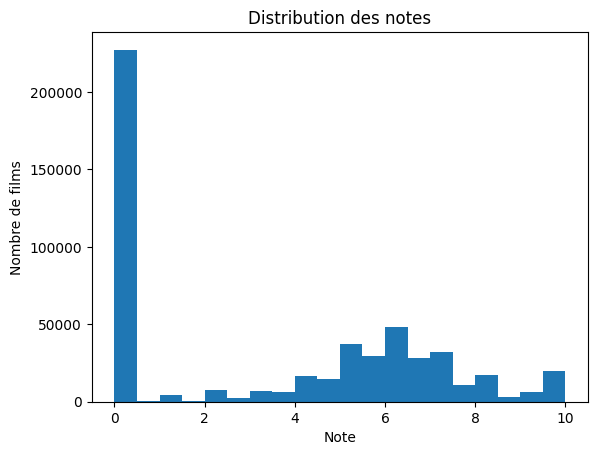

In [51]:
import matplotlib.pyplot as plt

plt.hist(df_movies['vote_average'], bins=20)
plt.title("Distribution des notes")
plt.xlabel("Note")
plt.ylabel("Nombre de films")
plt.show()

 On observe un grand nombre de films avec des notes très faibles (proches de 0)
 Cela s'explique par le fait que certains films ont peu ou pas de votes
 Ces notes ne sont donc pas fiables
 Il est donc nécessaire de filtrer les films selon le nombre de votes

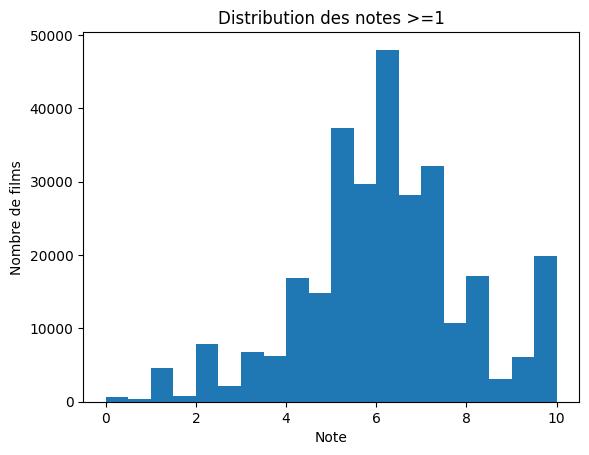

293131

In [52]:
df_filtered = df_movies[df_movies['vote_count'] >= 1]

plt.hist(df_filtered['vote_average'], bins=20)
plt.title("Distribution des notes >=1")
plt.xlabel("Note")
plt.ylabel("Nombre de films")
plt.show()

len(df_filtered)

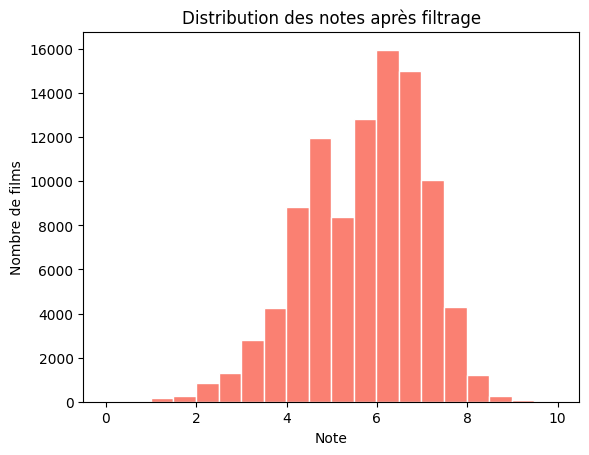

98606

In [53]:
mask_low = (df_movies['vote_count'] >= 3) & (df_movies['vote_average'] < 5)
mask_high = (df_movies['vote_count'] >= 10)  & (df_movies['vote_average'] < 10) & (df_movies['vote_average'] >= 5)
df_filtered = df_movies[mask_low | mask_high]

plt.hist(df_filtered['vote_average'], bins=20, color='salmon', edgecolor='white')
plt.title("Distribution des notes après filtrage")
plt.xlabel("Note")
plt.ylabel("Nombre de films")
plt.show()

len(df_filtered)

Le dataset contient beaucoup de films avec des notes faibles, mais cela est dû à un manque de votes. Après filtrage, on observe que la majorité des films ont une note entre 5 et 7.



---



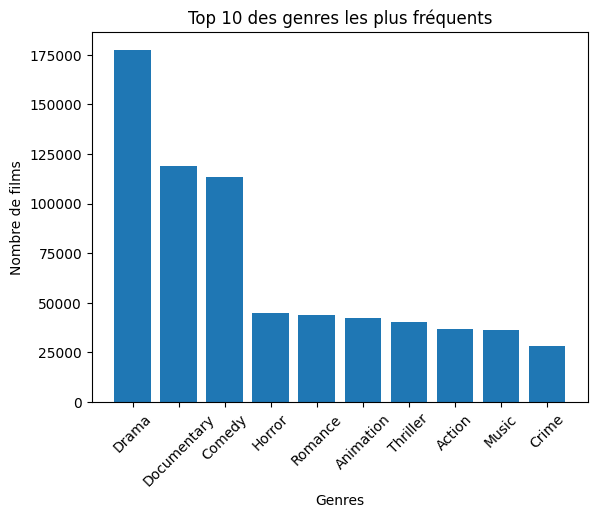

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Transformer la liste de genres en lignes
df_genres = df_movies.explode('genres')

# Compter le nombre de films par genre
genre_counts = df_genres['genres'].value_counts().head(10)

# Graphique
plt.figure()
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45)
plt.title("Top 10 des genres les plus fréquents")
plt.xlabel("Genres")
plt.ylabel("Nombre de films")
plt.show()

On utilise explode() pour transformer chaque genre en ligne
Exemple : ['Action', 'Comedy'] devient 2 lignes
Ensuite on compte le nombre de films par genre avec value_counts()

Les genres les plus fréquents sont Drama, Documentary et Comedy. Le genre Drama est très dominant. On remarque aussi une forte présence de documentaires, ce qui montre que le dataset ne contient pas uniquement des films commerciaux.



---



Nombre de films par année

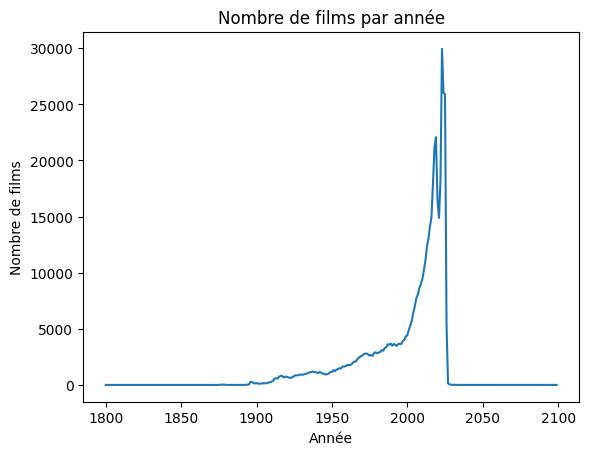

In [55]:
df_movies['year'] = pd.to_datetime(df_movies['release_date']).dt.year

films_per_year = df_movies['year'].value_counts().sort_index()

plt.figure()
plt.plot(films_per_year.index, films_per_year.values)
plt.title("Nombre de films par année")
plt.xlabel("Année")
plt.ylabel("Nombre de films")
plt.show()

Le nombre de films augmente avec le temps, ce qui montre une croissance de la production.



---



Note moyenne par année

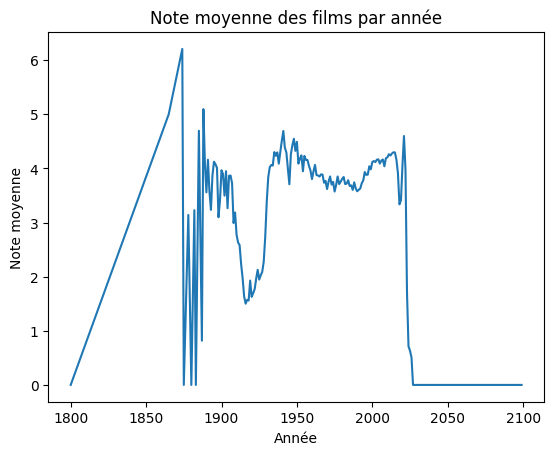

In [56]:
avg_rating_per_year = df_movies.groupby('year')['vote_average'].mean()

plt.figure()
plt.plot(avg_rating_per_year.index, avg_rating_per_year.values)
plt.title("Note moyenne des films par année")
plt.xlabel("Année")
plt.ylabel("Note moyenne")
plt.show()

La note moyenne reste globalement stable dans le temps.



---



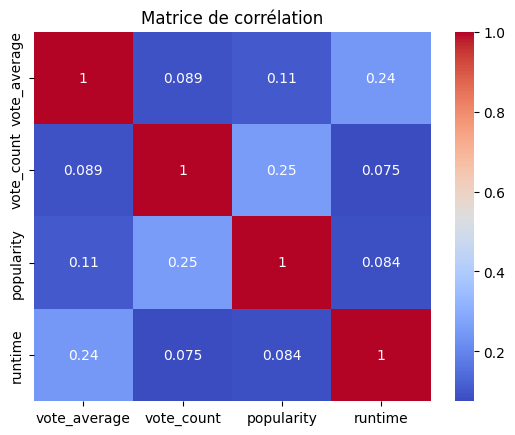

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# On sélectionne les colonnes numériques utiles
corr = df_movies[['vote_average', 'vote_count', 'popularity', 'runtime']].corr()

# Heatmap
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

# 5 - Système de recommandation TF-IDF + KNN

 Pourquoi combiner TF-IDF et KNN ?

**TF-IDF** transforme le texte (genres + description) en vecteurs
de chiffres. Il donne plus d'importance aux mots rares et
distinctifs, et moins d'importance aux mots très communs.

**KNN** (K-Nearest Neighbors) trouve les K films dont les vecteurs
sont les plus proches du film recherché.

**Ensemble** : TF-IDF prépare les données, KNN fait la recherche.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Filtre des films
mask_low = (df_movies['vote_average'] < 5) & (df_movies['vote_count'] >= 3)
mask_high = (df_movies['vote_average'] >= 5) & (df_movies['vote_count'] >= 10)
df_reco_filtered = df_movies[mask_low | mask_high].copy()

# Garder seulement les films avec une description
df_reco_filtered = df_reco_filtered[
    (df_reco_filtered['overview'].notna()) &
    (df_reco_filtered['overview'] != '')
].reset_index(drop=True)

# Préparer le contenu avec un POIDS ACCRU sur les genres
df_reco_filtered['genres_str'] = df_reco_filtered['genres'].apply(
    lambda x: ' '.join(x)
)

df_reco_filtered['content'] = (
    (df_reco_filtered['genres_str'] + ' ') * 2 +
    df_reco_filtered['overview']
)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', min_df=2)
matrix = vectorizer.fit_transform(df_reco_filtered['content'])

# KNN
knn = NearestNeighbors(n_neighbors=50, metric='cosine', algorithm='brute')
knn.fit(matrix)


NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=50)

In [59]:
# Calcul du nombre de films avec une note de 0
films_note_zero = (df_movies['vote_average'] == 0).sum()
print(f"Nombre de films avec une note de 0 : {films_note_zero}")

# Proportion par rapport au total
total_films = len(df_movies)
pourcentage = (films_note_zero / total_films) * 100
print(f"Cela représente {pourcentage:.2f}% du dataset.")

Nombre de films avec une note de 0 : 227324
Cela représente 43.72% du dataset.


In [60]:
df_reco_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96465 entries, 0 to 96464
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              96465 non-null  object 
 1   vote_average       96465 non-null  float64
 2   vote_count         96465 non-null  int64  
 3   release_date       96465 non-null  object 
 4   runtime            96465 non-null  int64  
 5   adult              96465 non-null  bool   
 6   original_language  96465 non-null  object 
 7   overview           96465 non-null  object 
 8   popularity         96465 non-null  float64
 9   poster_path        94550 non-null  object 
 10  genres             96465 non-null  object 
 11  year               96465 non-null  int32  
 12  genres_str         96465 non-null  object 
 13  content            96465 non-null  object 
dtypes: bool(1), float64(2), int32(1), int64(2), object(8)
memory usage: 9.3+ MB


# 7 - Fonction de recommandation

In [61]:
import re

def recommend_similar(title, top_n=5):
    if title not in df_reco_filtered['title'].values:
        print(f"Le film '{title}' n'a pas été trouvé.")
        return

    movie_position = df_reco_filtered[df_reco_filtered['title'] == title].index[0]

    # Récupérer les genres du film recherché
    film_genres = set(df_reco_filtered.iloc[movie_position]['genres'])

    distances, indices = knn.kneighbors(matrix[movie_position])

    def clean_title(t):
        return set(re.sub(r'[^\w\s]', '', t.lower()).split())

    title_words = clean_title(title)

    results_indices = []
    for dist, idx in zip(distances[0][1:], indices[0][1:]):
        film = df_reco_filtered.iloc[idx]

        # Exclure les quasi-doublons
        if dist < 0.05:
            continue

        # Exclure si titre trop similaire
        film_title_words = clean_title(film['title'])
        words_in_common = title_words & film_title_words
        if len(title_words) > 0 and len(words_in_common) / len(title_words) > 0.5:
            continue

        # Exclure les Documentaires si le film recherché n'est pas un Documentaire
        if 'Documentary' in film['genres'] and 'Documentary' not in film_genres:
            continue

        results_indices.append(idx)

        if len(results_indices) == top_n:
            break

    if not results_indices:
        print(f"Aucun film trouvé pour '{title}'.")
        return

    # On récupère les films recommandés et on les trie par note
    recommendations = df_reco_filtered.iloc[results_indices].copy()
    recommendations = recommendations.sort_values(by='vote_average', ascending=False)

    return recommendations[['title', 'genres', 'vote_average']]

In [62]:
def check_genre_similarity(input_title, recommendations_df):
    # Récupérer les genres du film de référence
    input_genres = set(df_reco_filtered[df_reco_filtered['title'] == input_title]['genres'].values[0])

    print(f"Genres de référence ({input_title}): {input_genres}\n")

    for _, row in recommendations_df.iterrows():
        reco_genres = set(row['genres'])
        common = input_genres.intersection(reco_genres)
        similarity = (len(common) / len(input_genres)) * 100

        print(f"Film: {row['title']}")
        print(f"Genres: {row['genres']}")
        print(f"Similitude genres: {similarity:.1f}% ({len(common)} en commun)")
        print("-" * 30)

# Test après augmentation du poids des genres
recos = recommend_similar("marvel")
if recos is not None:
    check_genre_similarity("marvel", recos)


Le film 'marvel' n'a pas été trouvé.


# 8 - Test avec plusieurs films

In [63]:
print("=== Inception ===")
print(recommend_similar("Inception"))

print("=== The Dark Knight ===")
print(recommend_similar("The Dark Knight"))

print("=== Titanic ===")
print(recommend_similar("Titanic"))

=== Inception ===
                             title  \
52648               The Flying Man   
17973  Inhumans: The First Chapter   
16584                 Alien Hunter   
62027                       Prince   
60592                Savage Planet   

                                             genres  vote_average  
52648            [Action, Mystery, Science Fiction]         5.400  
17973          [Science Fiction, Action, Adventure]         5.297  
16584          [Science Fiction, Action, Adventure]         5.200  
62027           [Action, Science Fiction, Thriller]         4.900  
60592  [Science Fiction, Action, Adventure, Horror]         3.300  
=== The Dark Knight ===
                                     title  \
6085  Batman: The Long Halloween, Part One   
6932  Batman: The Long Halloween, Part Two   
487                                 Batman   
2541              Batman: The Killing Joke   
9466                              Ricochet   

                                   genres  v

### Propositions pour optimiser la recommandation

1. **Pondération Dégressive** : Faire varier le poids des genres à sur une intervalle de 1 à 5 pour laisser l'overview influencer le classement final.
2. **Normalisation de la longueur** : Utiliser un paramètre `sublinear_tf=True` dans le TfidfVectorizer pour atténuer l'impact de la répétition des mots. ( à tester et vérifier les écarts de performance)
3. **Système Hybride - Détail du résultat** : Calculer deux scores séparés (un score Genre, un score Overview) et faire une moyenne pondérée (ex: 70% overview, 30% genre).

Pondération dégressive des genres

In [64]:
# Pondération dégressive : on teste différents poids pour les genres
# et on garde le meilleur

resultats_poids = {}

for poids in [1, 2, 3, 4, 5]:
    # Créer le contenu avec ce poids
    df_test = df_reco_filtered.copy()
    df_test['content_test'] = (
        (df_test['genres_str'] + ' ') * poids +
        df_test['overview']
    )

    # TF-IDF
    vec_test = TfidfVectorizer(stop_words='english', min_df=2)
    mat_test = vec_test.fit_transform(df_test['content_test'])

    # KNN
    knn_test = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
    knn_test.fit(mat_test)

    # Tester sur Inception
    pos = df_test[df_test['title'] == 'Inception'].index[0]
    distances, indices = knn_test.kneighbors(mat_test[pos])

    # Calculer la similarité genre moyenne des recommandations
    input_genres = set(df_test.iloc[pos]['genres'])
    similarities = []
    for idx in indices[0][1:6]:
        reco_genres = set(df_test.iloc[idx]['genres'])
        common = input_genres & reco_genres
        if len(input_genres) > 0:
            similarities.append(len(common) / len(input_genres))

    score_moyen = sum(similarities) / len(similarities) if similarities else 0
    resultats_poids[poids] = score_moyen
    print(f"Poids genres = {poids} → Similarité genre moyenne : {score_moyen*100:.1f}%")

# Trouver le meilleur poids
meilleur_poids = max(resultats_poids, key=resultats_poids.get)
print(f"\n✅ Meilleur poids : {meilleur_poids} (similarité genre : {resultats_poids[meilleur_poids]*100:.1f}%)")

Poids genres = 1 → Similarité genre moyenne : 13.3%
Poids genres = 2 → Similarité genre moyenne : 86.7%
Poids genres = 3 → Similarité genre moyenne : 100.0%
Poids genres = 4 → Similarité genre moyenne : 100.0%
Poids genres = 5 → Similarité genre moyenne : 100.0%

✅ Meilleur poids : 3 (similarité genre : 100.0%)


Comparer TF-IDF normal vs sublinear_tf=True

In [65]:
# Comparer TF-IDF normal vs sublinear_tf=True

print("=== Sans sublinear_tf ===")
vec_normal = TfidfVectorizer(stop_words='english', min_df=2)
mat_normal = vec_normal.fit_transform(df_reco_filtered['content'])
knn_normal = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn_normal.fit(mat_normal)

print("=== Avec sublinear_tf=True ===")
vec_sub = TfidfVectorizer(stop_words='english', min_df=2, sublinear_tf=True)
mat_sub = vec_sub.fit_transform(df_reco_filtered['content'])
knn_sub = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn_sub.fit(mat_sub)

# Comparer les recommandations pour Inception
pos = df_reco_filtered[df_reco_filtered['title'] == 'Inception'].index[0]
input_genres = set(df_reco_filtered.iloc[pos]['genres'])

def get_genre_score(mat, knn_model, pos, df):
    distances, indices = knn_model.kneighbors(mat[pos])
    scores = []
    for idx in indices[0][1:6]:
        reco_genres = set(df.iloc[idx]['genres'])
        common = input_genres & reco_genres
        scores.append(len(common) / len(input_genres) if input_genres else 0)
    return sum(scores) / len(scores) if scores else 0

score_normal = get_genre_score(mat_normal, knn_normal, pos, df_reco_filtered)
score_sub = get_genre_score(mat_sub, knn_sub, pos, df_reco_filtered)

print(f"\nSimilarité genre sans sublinear_tf : {score_normal*100:.1f}%")
print(f"Similarité genre avec sublinear_tf : {score_sub*100:.1f}%")

if score_sub > score_normal:
    print("✅ sublinear_tf=True est meilleur → on l'utilise !")
    vectorizer = vec_sub
    matrix = mat_sub
    knn = knn_sub
else:
    print("✅ Sans sublinear_tf est meilleur → on garde l'original !")

=== Sans sublinear_tf ===
=== Avec sublinear_tf=True ===

Similarité genre sans sublinear_tf : 86.7%
Similarité genre avec sublinear_tf : 80.0%
✅ Sans sublinear_tf est meilleur → on garde l'original !


Système hybride (score genre + score overview)

In [66]:
# Système hybride : 2 scores séparés
# Score genre    : basé uniquement sur les genres
# Score overview : basé uniquement sur la description
# Score final    : 30% genre + 70% overview

from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

# Vectoriser les genres seuls
vec_genres = TfidfVectorizer(stop_words='english')
mat_genres = vec_genres.fit_transform(df_reco_filtered['genres_str'])

# Vectoriser l'overview seul
vec_overview = TfidfVectorizer(stop_words='english', min_df=2)
mat_overview = vec_overview.fit_transform(df_reco_filtered['overview'].fillna(''))

def recommend_hybrid(title, top_n=5, poids_genre=0.3, poids_overview=0.7):
    if title not in df_reco_filtered['title'].values:
        print(f"Le film '{title}' n'a pas été trouvé.")
        return

    pos = df_reco_filtered[df_reco_filtered['title'] == title].index[0]
    film_genres = set(df_reco_filtered.iloc[pos]['genres'])

    # Score genre
    score_genre = cos_sim(mat_genres[pos], mat_genres).flatten()

    # Score overview
    score_overview = cos_sim(mat_overview[pos], mat_overview).flatten()

    # Score final pondéré
    score_final = (poids_genre * score_genre) + (poids_overview * score_overview)

    # Trier par score final
    top_indices = score_final.argsort()[::-1]

    import re
    def clean_title(t):
        return set(re.sub(r'[^\w\s]', '', t.lower()).split())

    title_words = clean_title(title)
    results = []

    for idx in top_indices:
        if idx == pos:
            continue

        film = df_reco_filtered.iloc[idx]

        # Exclure titres trop similaires
        film_title_words = clean_title(film['title'])
        words_in_common = title_words & film_title_words
        if len(title_words) > 0 and len(words_in_common) / len(title_words) > 0.5:
            continue

        # Exclure documentaires
        if 'Documentary' in film['genres'] and 'Documentary' not in film_genres:
            continue

        results.append(idx)

        if len(results) == top_n:
            break

    if not results:
        print(f"Aucun film trouvé pour '{title}'.")
        return

    recommendations = df_reco_filtered.iloc[results].copy()
    recommendations = recommendations.sort_values(by='vote_average', ascending=False)
    return recommendations[['title', 'genres', 'vote_average']]

# Comparaison KNN classique vs Hybride
print("=== KNN classique ===")
print(recommend_similar("Inception"))

print("\n=== Système Hybride (30% genre + 70% overview) ===")
print(recommend_hybrid("Inception"))

print("\n=== Système Hybride (50% genre + 50% overview) ===")
print(recommend_hybrid("Inception", poids_genre=0.5, poids_overview=0.5))

=== KNN classique ===
                             title  \
52648               The Flying Man   
17973  Inhumans: The First Chapter   
16584                 Alien Hunter   
62027                       Prince   
60592                Savage Planet   

                                             genres  vote_average  
52648            [Action, Mystery, Science Fiction]         5.400  
17973          [Science Fiction, Action, Adventure]         5.297  
16584          [Science Fiction, Action, Adventure]         5.200  
62027           [Action, Science Fiction, Thriller]         4.900  
60592  [Science Fiction, Action, Adventure, Horror]         3.300  

=== Système Hybride (30% genre + 70% overview) ===
                                                   title  \
8                                Guardians of the Galaxy   
26904                                         Major Grom   
404                  Transformers: Revenge of the Fallen   
16970                                           C

In [67]:
from google.colab import files

df_reco_filtered.to_csv('TMDB_cleaned.csv', index=False)
files.download('TMDB_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>